In [3]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Let's continue on with our example about heights. We'll simulate an experiment where I have randomly sampled 1000 people whose sex is female and measured their height. 

In [4]:
n_samples = 1000

# Set random seed for reproducibility
rng = np.random.default_rng(2)

# Generate the data 
data = stats.norm.rvs(loc=167.4, 
                      scale=7.1, 
                      size=n_samples, 
                      random_state=rng)

# Create a dataframe with the data
df = pd.DataFrame({'height': data})

And let's visualize the distribution, as we almost always will do when we're inspecting a dataset. 

Text(0.5, 0, 'Height (cm)')

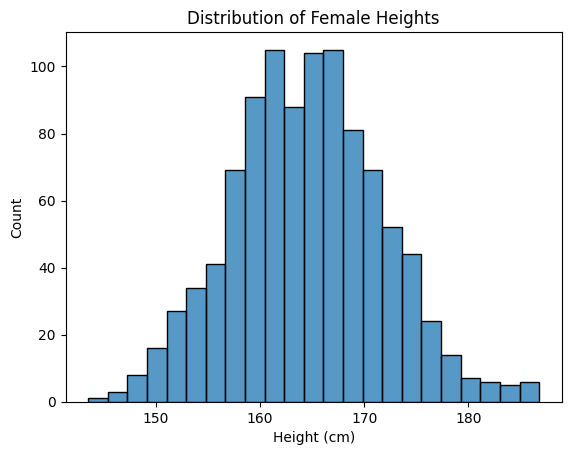

In [6]:
sns.histplot(data=df, x='height')
plt.title("Distribution of Female Heights")
plt.xlabel("Height (cm)")

To reason about how much spread this distribution has, we _could_ calculate percentiles, like before. But, we know something about the data. Heights are normally distributed. And that means we can combine our actual measurements with what we know about normal distributions from theory.

Remember, the normal distribution follows a formula! It has a probability density function: 

$$ f(x | \mu, \sigma) = \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{(x - \mu)^2}{2 \sigma^2 }} $$
where:
 - x is any real number, positive or negative.
 - μ is the mean of the distribution.
 - σ is the standard deviation of the distribution
 - π is a mathematical constant, approximately equal to 3.14159.

If we know the mean of our distribution and its standard deviation, we can let the `scipy.stats` module take care of everything else! 

In [11]:
sample_mu = df.height.mean()
print("The sample mean is", sample_mu)
sample_sigma = df.height.std()
print("The sample standard deviation is", sample_sigma)

The sample mean is 164.5408956694359
The sample standard deviation is 7.194673378838189


Now lets use those values to visualize the theoretical distribution: 

<Axes: xlabel='height', ylabel='Density'>

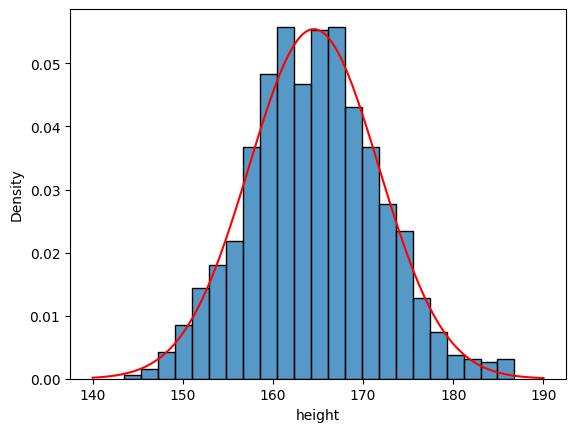

In [12]:
x = np.linspace(140, 190, 100)
y = stats.norm.pdf(x, sample_mu, sample_    sigma) 
# Calculate the probability density function (PDF) for the normal distribution
pdf = pd.DataFrame({"height": x,
                    "probability": y})

# Plot the PDF in seaborn
sns.histplot(data=df, x='height', stat='density') 
# Add the lineplot over this
sns.lineplot(data=pdf, x='height', y='probability', color='red')


The normal distribution is special in statistics. It has a nice relationship between a measure of width- its standard deviation- and percentiles. 

_Note: the below figure comes from [Modern Dive](https://moderndive.com/A-appendixA.html#appendix-normal-curve), a wonderful open-source textbook about statistics in R._

![image.png](https://moderndive.com/ModernDive_files/figure-html/normal-rule-of-thumb-1.png)

We can use the standard deviation to partition up the normal distribution. Without doing any programming, see if you can calculate: 
- What proportion of the area under the curve is above z = 2?
- What proportion of the area under the curve is between z = -1 and z = 1? 
- What is the 2.5th percentile of the area under the normal curve?

But for our data, we don't have z-scores - we have heights in centimenters. Luckily, there's a formula to make the conversion:  
$$ z = {{x - \mu} \over \sigma }$$

We can calculate this by hand using `numpy`:

In [16]:
df['z'] = (df.height - sample_mu) / sample_sigma
df.head()

And even more handily, there is a function that will do the calculation for us in `scipy.stats`:

In [ ]:
df['z2'] = stats.zscore(df.height)
df.head()

It's common to use standard deviations to describe how ordinary or extraordinary a particular observation is. If a given observation is 1 standard deviation above the mean- is it noteworthy? Let's go back and check our helpful reference figure about z-scores. 
